In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, Model
from keras.src.legacy.preprocessing.image import ImageDataGenerator


In [4]:
def extract_patches(image, patch_size=32, stride=16):
    """Extract overlapping patches from an image"""
    patches = tf.image.extract_patches(
        images=tf.expand_dims(image, 0), # artificially increase the dimensions to (1, w, h, c), necessary for extract function
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1], # rates is used for dilatation 
        padding='VALID' # Only use fully contained patches
    )
    return tf.reshape(patches, [-1, patch_size, patch_size, image.shape[-1]]) # reshape patches to (num_patches, w, h, c)

# Example usage:
# n = 224
# images = np.array([[[x * n + y + 1] for y in range(n)] for x in range(n)]) 
# print(extract_patches(images).shape) # outputs 169,32,32,1

In [5]:
class PatchBagGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_arrays, labels, patch_size=32, stride=16, batch_size=32):
        """
        Args:
            image_arrays: Array of preloaded images (h,w,c)
            labels: Corresponding labels
            patch_size: Size of square patches
            stride: Step between patches
            batch_size: Number of images per batch
        """
        self.image_arrays = image_arrays
        self.labels = labels
        self.patch_size = patch_size
        self.stride = stride
        self.batch_size = batch_size
        self.num_samples = len(image_arrays)
        self.indices = np.arange(self.num_samples)
        assert self.image_arrays.shape == (self.num_samples, 224, 224, 1), "Image arrays shape mismatch: {} vs {}".format(image_arrays.shape, (self.num_samples, 224, 224, 1))
                
    def __len__(self):
        return int(np.ceil(self.num_samples / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size:(index+1)*self.batch_size] # retrieve indices for current batch index
        batch_images = [self.image_arrays[i] for i in batch_indices] # retrieve images for current batch
        batch_labels = [self.labels[i] for i in batch_indices] # retrieve labels for current batch
        
        # Process each image into patches
        batch_bags = []
        for img in batch_images:
            batch_bags.append(extract_patches(img, patch_size=self.patch_size, stride=self.stride)) 
                
        return np.array(batch_bags), np.array(batch_labels)
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices) # randomize batches for next epoch

In [6]:
def extract_generator_data(generator):
    """Convert generator output to arrays"""
    images, labels = [], []
    generator.reset() # ensure to retrieve all data from generator start
    for i in range(len(generator)):
        batch_img, batch_lbl = generator[i]
        images.append(batch_img)
        labels.append(batch_lbl)
    return np.vstack(images), np.vstack(labels)

# initialize generator for data retrieval
train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_path = "C:\\Users\\Borajin\\.cache\\data\\preprocessed\\Training"

# create training and validation generators from data
train_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode="grayscale"
)

val_dir_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode="grayscale"
)

# convert generators to Data array containing images and label vector containing classes
X_train, y_train = extract_generator_data(train_dir_gen)
X_val, y_val = extract_generator_data(val_dir_gen)

print("Class indices:", train_dir_gen.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [7]:
from tensorflow.keras.applications import VGG16
def create_basic_mil_model(patch_size=32, num_classes=4):
    """Create MIL model using max/mean pooling"""
    
    # Instance-level model (processes individual patches)
    instance_input = layers.Input(shape=(patch_size, patch_size, 1))
    x = layers.Concatenate(axis=-1)([instance_input, instance_input, instance_input])
    
    # Feature extractor
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=(patch_size, patch_size, 3), pooling='avg')
    vgg.trainable = False
    
    x = vgg(x)
    instance_output = layers.Dense(128, activation='relu')(x)
    
    instance_model = Model(instance_input, instance_output)
    
    
    # Bag-level model applying the instance level model to each of the patches (using TimeDistributed)
    bag_input = layers.Input(shape=(None, patch_size, patch_size, 1))
    x = layers.TimeDistributed(instance_model)(bag_input)
  
    x = layers.GlobalMaxPooling1D()(x)
    bag_representation = layers.Dropout(0.5)(x)
    
    # Classification head
    output = layers.Dense(num_classes, activation='softmax')(bag_representation)
    
    return Model(bag_input, output)

In [8]:
# Create and compile model
model = create_basic_mil_model(patch_size=32, num_classes=4)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create data generators 
train_mil_gen = PatchBagGenerator(
    image_arrays=X_train,
    labels=y_train,
    patch_size=32,
    stride=32,
    batch_size=32
)

val_mil_gen = PatchBagGenerator(
    image_arrays=X_val,
    labels=y_val,
    patch_size=32,
    stride=32,
    batch_size=32
)

# Train
history = model.fit(
    train_mil_gen,
    validation_data=val_mil_gen,
    epochs=10
)

Epoch 1/10


C:\Users\Borajin\miniconda3\envs\BrainTumorDetection\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


72/72 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.4682 - loss: 8.8673 - val_accuracy: 0.5271 - val_loss: 6.0149
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7979 - loss: 1.7213 - val_accuracy: 0.5096 - val_loss: 6.2211
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9032 - loss: 0.5350 - val_accuracy: 0.6021 - val_loss: 5.4440
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9427 - loss: 0.2494 - val_accuracy: 0.5916 - val_loss: 5.2856
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9865 - loss: 0.0382 - val_accuracy: 0.6248 - val_loss: 4.8785
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9877 - loss: 0.0267 - val_accuracy: 0.5934 - val_loss: 4.9581
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9999 - loss: 0.0035 - val_accuracy: 0.6038 - val_loss: 4.8908
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.5986 - val_loss: 4.8976
Epo

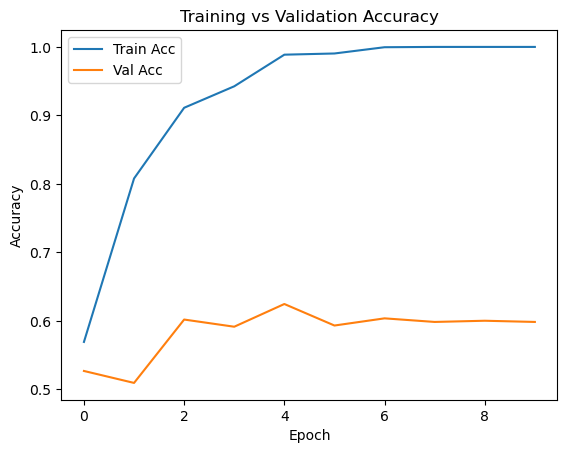

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()